In [32]:
led_img= "C:\\Users\\arite\\Desktop\\ASM RA\\ASM_Killifish_repo\\d48_65_s1.png"
no_led_img = "/Users/asmlabuser1/Scripts_Ari/no_led.png"

In [5]:
from skimage import measure, color
import numpy as np
import argparse
import imutils
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

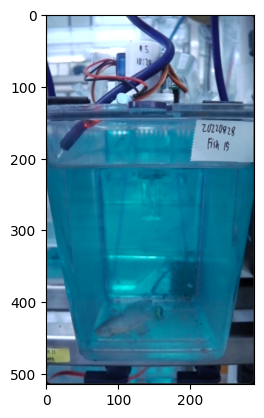

In [34]:
led = cv2.cvtColor(cv2.imread(led_img), cv2.COLOR_BGR2RGB)
# no_led = cv2.cvtColor(cv2.imread(no_led_img), cv2.COLOR_BGR2RGB)
plt.imshow(led)

In [35]:
print(led[0][0]) #pixel of normal image
led_LAB = color.rgb2lab(led)
# led_LAB = led
print(led_LAB[0][0])

[0 0 0]
[0. 0. 0.]


In [36]:
pixels = []
for i,y in enumerate(led_LAB):
    for j, x in enumerate(y):
        if x[0] > 35 and x[1] > 25 and -20<x[2]<40:
            pixels.append([i,j])
pixels_np = np.asarray(pixels)
print(pixels_np)

[[ 68  68]
 [ 68  69]
 [ 68  70]
 [ 68  71]
 [ 68  72]
 [ 69  66]
 [ 69  67]
 [ 69  68]
 [ 69  69]
 [ 70  64]
 [ 70  65]
 [ 70  66]
 [ 70  67]
 [ 71  63]
 [ 71  64]
 [ 71  65]
 [ 72  62]
 [ 72  63]
 [ 72  64]
 [ 74  58]
 [ 74  59]
 [ 75  57]
 [ 76  56]
 [ 76  57]
 [ 78  55]
 [ 79  55]
 [ 80  55]
 [ 81  55]
 [ 82  55]
 [ 82  56]
 [ 83  55]
 [ 83  56]
 [ 83  57]
 [ 84  56]
 [ 84  57]
 [ 84  58]
 [ 84  59]
 [ 84  60]
 [ 84  61]
 [ 85  58]
 [ 85  59]
 [ 85  60]
 [ 85  61]
 [ 85  62]
 [ 85  63]
 [ 85  64]
 [ 85  65]
 [ 85  66]
 [ 85  67]
 [ 85  68]
 [ 85  69]
 [ 85  70]
 [ 85  71]
 [ 86  60]
 [ 86  61]
 [ 86  62]
 [ 86  63]
 [ 86  64]
 [ 86  65]
 [ 86  66]
 [ 86  67]
 [ 86  68]
 [ 86  69]
 [ 86  70]
 [ 86  71]
 [ 86  72]
 [ 86  73]
 [ 86  74]
 [ 87  64]
 [ 87  65]
 [ 87  66]
 [ 87  67]
 [ 87  68]
 [ 87  69]
 [ 87  70]
 [ 87  71]
 [ 87  72]
 [ 87  73]
 [ 87  74]
 [ 87  75]
 [ 87  76]
 [ 87  77]
 [ 87  78]
 [ 87  79]
 [ 87  80]
 [ 87  81]
 [ 87  82]
 [ 87  83]
 [ 87  84]
 [ 87  85]
 [ 87  86]

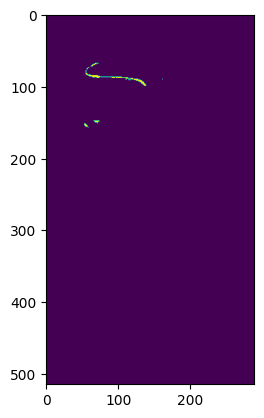

In [37]:
mask = np.zeros((len(led), len(led[0])))
for [i,j] in pixels:
    mask[i][j] = 255
plt.imshow(mask)

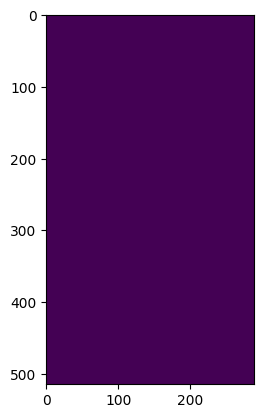

In [38]:
mask2 = cv2.dilate(mask2, None, iterations=1)
mask2 = cv2.erode(mask, None, iterations=3)

plt.imshow(mask2)

In [39]:
print(no_led[0][0]) #pixel of normal image
no_led_LAB = color.rgb2lab(no_led)
print(no_led_LAB[0][0])

NameError: name 'no_led' is not defined

In [ ]:
pixels_no = []
for i,y in enumerate(no_led_LAB):
    for j, x in enumerate(y):
        if x[0] > 35 and x[1] > 25 and -20<x[2]<40:
            pixels_no.append([i,j])
# pixels_np_no = np.asarray(pixels_no)
# print(pixels_np)

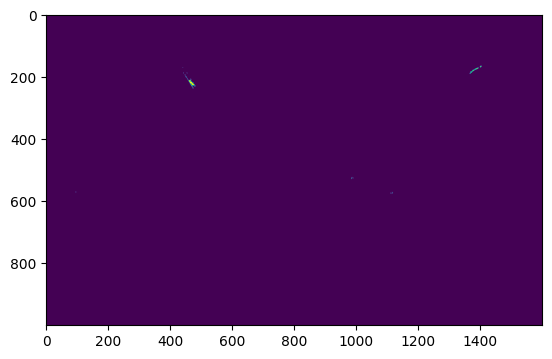

In [ ]:
mask_no = np.zeros((1000,1600))
for [i,j] in pixels_no:
    mask_no[i][j] = 255
plt.imshow(mask_no)

In [ ]:
mask_no2 = cv2.erode(mask_no, None, iterations=3)
mask_no2 = cv2.dilate(mask_no2, None, iterations=8)
plt.imshow(mask_no2)

NameError: name 'mask_no' is not defined

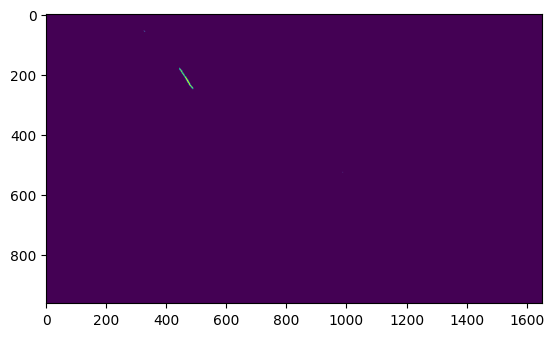

In [45]:
led_img= "C:\\Users\\arite\\Desktop\\ASM RA\\ASM_Killifish_repo\\no_led.png"

led = cv2.cvtColor(cv2.imread(led_img), cv2.COLOR_BGR2RGB)
led_LAB = color.rgb2lab(led)

and_mask = np.logical_and(led_LAB[:, :, 0] > 25, led_LAB[:, :, 1] > 25)
and_mask = np.logical_and(and_mask, np.logical_and(led_LAB[:, :, 2] > -20, led_LAB[:, :, 2] < 40))
pixels1 = np.argwhere(and_mask)

mask_bw = np.zeros((len(led_LAB), len(led_LAB[0])))
mask_bw[pixels1[:, 0], pixels1[:, 1]] = 255

mask2 = cv2.dilate(mask_bw, None, iterations=3)
mask_erode = cv2.erode(mask2, None, iterations=5)

plt.imshow(mask_erode)

Work on videos + is some sort of verification needed??

## video


In [58]:

vid_path=Path("C:/Users/arite/Desktop/ASM RA/ASM_Killifish_repo/d48_23_T3.mp4")
# capture = cv2.VideoCapture(vid_path)

video = cv2.VideoCapture("d48_65_S1.mp4")

In [59]:
total_frames = int(video.get(cv2.CAP_PROP_FRAME_COUNT))
progress_bar = tqdm(total=total_frames)


pixels_count=[]
# Read until video is completed
while(video.isOpened()):

  # Capture frame-by-frame
  ret, frame = video.read()
  if ret == True:
    # Display the resulting frame
    # cv2.imshow('Frame',frame)
    # plt.imshow(frame)
 
    # Press Q on keyboard to  exit
    if cv2.waitKey(25) & 0xFF == ord('q'):
      break
    led = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    # cv2.imshow('Frame',led_LAB)
    led_LAB = color.rgb2lab(led)


    and_mask = np.logical_and(led_LAB[:, :, 0] > 55, led_LAB[:, :, 1] > 25)
    and_mask = np.logical_and(and_mask, np.logical_and(led_LAB[:, :, 2] > -20, led_LAB[:, :, 2] < 40))

    # Get the indices of the elements that meet the criteria
    pixels1 = np.argwhere(and_mask)
    if pixels1.size > 0:
      # print("entering loop")
      mask_bw = np.zeros((len(frame), len(frame[0])))
      pixels_count.append(pixels1.size)
      # for [i,j] in pixels1:
      #     mask[i][j] = 255
      mask_bw[pixels1[:, 0], pixels1[:, 1]] = 255
      # cv2.imshow('mask',mask_bw)
      # plt.imshow(mask)
      # cv2.imshow('mask', mask)
      # mask2 = cv2.dilate(mask_bw, None, iterations=3)
      # mask_erode = cv2.erode(mask_erode, None, iterations=4)
      cv2.imshow('mask',mask_bw)
    progress_bar.update(1)
  # Break the loop
  else: 
    break
  

# When everything done, release the video capture object
video.release()
# progress_bar.close()

 
# Closes all the frames
cv2.destroyAllWindows()


  6%|▌         | 314/5490 [05:08<1:42:42,  1.19s/it]

In [57]:
video.release()
